# ROOTKey A/B Test — Analysis Notebook

*Real data is pending from the company. This analysis uses simulated data anchored to real observations (baseline conversion rate, 50/50 split). Approved by the instructor.*


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

BLUE  = '#2563EB'
GREEN = '#16A34A'
RED   = '#DC2626'
GRAY  = '#6B7280'


---
## 1. Power Calculation

Before running any experiment, you need to know how many visitors you need to reliably detect a meaningful effect. We should have done this upfront — we didn't, and that hurt us.

Formula for equal group sizes:

**n = ( (Z₁₋α/₂ + Z₁₋β)² · σ² ) / δ²**

- σ² = p·(1−p): variance of the binary outcome
- δ: minimum effect size worth detecting
- α = 0.05, power = 80%

Baseline anchored at **10%** — the conversion rate observed on Version A in the real test.


In [26]:
p_A     = 0.10
delta   = 0.06
alpha   = 0.05
power_t = 0.80

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta  = stats.norm.ppf(power_t)
sigma2  = p_A * (1 - p_A)

n_per_group = int(np.ceil((z_alpha + z_beta)**2 * sigma2 / delta**2))
n_total     = n_per_group * 2

print(f'Baseline conversion (p_A):     {p_A*100:.0f}%')
print(f'Min detectable effect (delta): {delta*100:.0f}pp')
print(f'sigma^2 = p*(1-p):             {sigma2:.4f}')
print(f'Z_alpha/2:                     {z_alpha:.3f}')
print(f'Z_beta:                        {z_beta:.3f}')
print()
print(f'Required n per group:          {n_per_group}')
print(f'Required total (50/50):        {n_total}')


Baseline conversion (p_A):     10%
Min detectable effect (delta): 6pp
sigma^2 = p*(1-p):             0.0900
Z_alpha/2:                     1.960
Z_beta:                        0.842

Required n per group:          197
Required total (50/50):        394


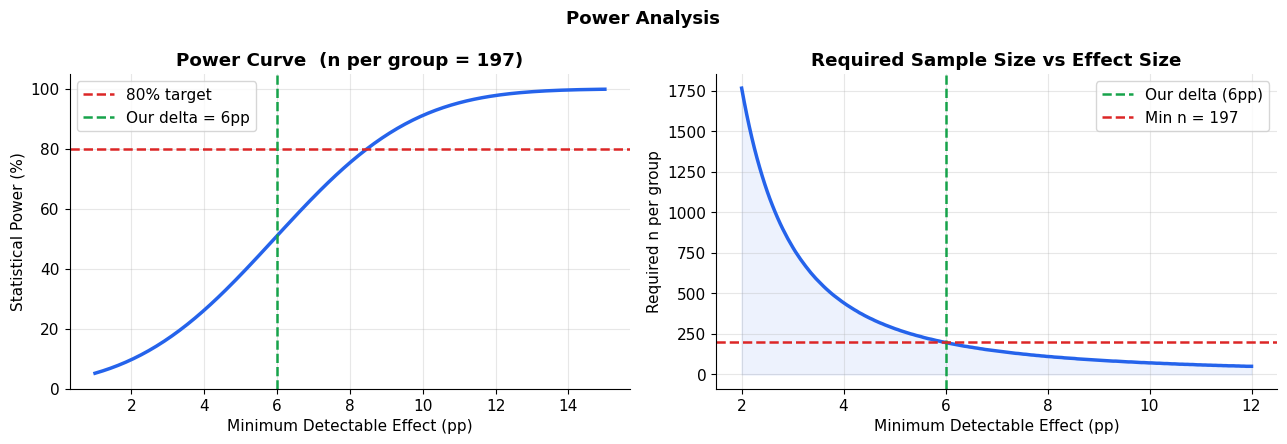

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

effects = np.linspace(0.01, 0.15, 200)
powers  = [stats.norm.cdf(e / np.sqrt(2 * sigma2 / n_per_group) - z_alpha) * 100
           for e in effects]
axes[0].plot([e*100 for e in effects], powers, color=BLUE, lw=2.5)
axes[0].axhline(80, color=RED, ls='--', lw=1.8, label='80% target')
axes[0].axvline(delta*100, color=GREEN, ls='--', lw=1.8, label=f'Our delta = {delta*100:.0f}pp')
axes[0].set_xlabel('Minimum Detectable Effect (pp)')
axes[0].set_ylabel('Statistical Power (%)')
axes[0].set_title(f'Power Curve  (n per group = {n_per_group})', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 105)
axes[0].spines[['top','right']].set_visible(False)

effects_r = np.linspace(0.02, 0.12, 200)
ns = [int(np.ceil((z_alpha + z_beta)**2 * sigma2 / e**2)) for e in effects_r]
axes[1].plot([e*100 for e in effects_r], ns, color=BLUE, lw=2.5)
axes[1].axvline(delta*100, color=GREEN, ls='--', lw=1.8, label=f'Our delta ({delta*100:.0f}pp)')
axes[1].axhline(n_per_group, color=RED, ls='--', lw=1.8, label=f'Min n = {n_per_group}')
axes[1].fill_between([e*100 for e in effects_r], ns, alpha=0.08, color=BLUE)
axes[1].set_xlabel('Minimum Detectable Effect (pp)')
axes[1].set_ylabel('Required n per group')
axes[1].set_title('Required Sample Size vs Effect Size', fontweight='bold')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Power Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 2. EDA

We describe the data comprehensively before running any formal tests.


### 2.1 Traffic distribution

In [28]:
df = pd.read_csv('rootkey_ab_data.csv')
print(f'Total observations: {len(df)}')
print(f'Variables: {list(df.columns)}')
print()
print(df.groupby('variant').size().rename('N').to_frame().T.to_string())
print()
df.head(10)


Total observations: 1000
Variables: ['visitor_id', 'variant', 'converted', 'time_on_page_sec', 'bounce']

variant    A    B
N        500  500



,visitor_id,variant,converted,time_on_page_sec,bounce
0,522,B,1,61.5,0
1,738,B,1,97.2,1
2,741,B,0,77.3,0
3,661,B,0,59.1,1
4,412,A,1,58.6,1
5,679,B,0,61.3,0
6,627,B,0,55.2,1
7,514,B,0,41.7,0
8,860,B,0,34.7,0
9,137,A,0,31.7,0


### 2.2 KPI - Conversion rate

In [29]:
# Summary statistics by variant
summary = df.groupby('variant').agg(
    N               = ('converted',        'count'),
    Conversions     = ('converted',        'sum'),
    Conversion_Rate = ('converted',        'mean'),
    Conv_SD         = ('converted',        'std'),
    Time_Mean_s     = ('time_on_page_sec', 'mean'),
    Time_SD_s       = ('time_on_page_sec', 'std'),
    Bounce_Mean     = ('bounce',           'mean'),
    Bounce_SD       = ('bounce',           'std'),
).round(4)
summary['Conversion_%'] = (summary['Conversion_Rate'] * 100).round(2)
summary['Bounce_%']     = (summary['Bounce_Mean']     * 100).round(2)
print(summary.to_string())


           N  Conversions  Conversion_Rate  Conv_SD  Time_Mean_s  Time_SD_s  Bounce_Mean  Bounce_SD  Conversion_%  Bounce_%
variant                                                                                                                    
A        500           55            0.110   0.3132      45.2564    19.9042        0.550      0.498          11.0      55.0
B        500           78            0.156   0.3632      62.0180    21.0565        0.478      0.500          15.6      47.8


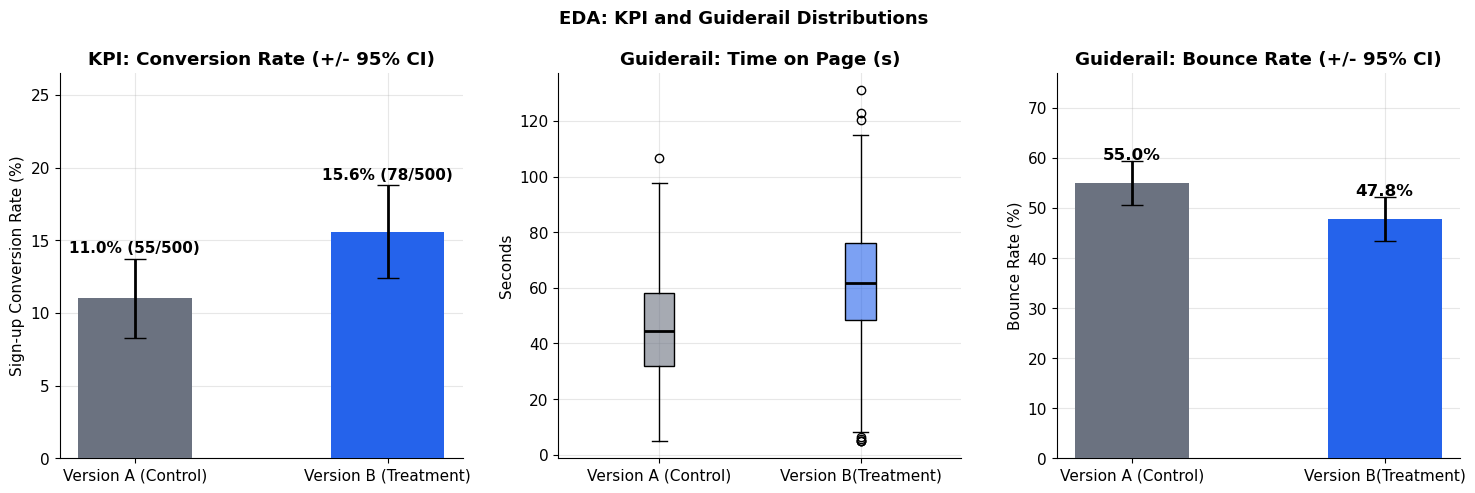

In [30]:
# KPI distribution — bar chart + boxplot for time on page
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Conversion rate with CI (binary — bar is more appropriate than boxplot)
conv  = df.groupby('variant')['converted'].agg(['mean','count','sum'])
conv['ci95'] = 1.96 * np.sqrt(conv['mean']*(1-conv['mean'])/conv['count'])
rates = conv['mean'].values * 100
cis   = conv['ci95'].values * 100
bars = axes[0].bar(conv.index, rates, color=[GRAY, BLUE], width=0.45, zorder=3)
axes[0].errorbar(conv.index, rates, yerr=cis,
                 fmt='none', color='black', capsize=8, lw=2, zorder=4)
for bar, r, ci, c, n in zip(bars, rates, cis,
                              conv['sum'].values, conv['count'].values):
    axes[0].text(bar.get_x()+bar.get_width()/2, r+ci+0.4,
                 f'{r:.1f}% ({int(c)}/{int(n)})',
                 ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('KPI: Conversion Rate (+/- 95% CI)', fontweight='bold')
axes[0].set_ylabel('Sign-up Conversion Rate (%)')
axes[0].set_ylim(0, max(rates)*1.7)
axes[0].spines[['top','right']].set_visible(False)
axes[0].set_xticklabels(['Version A (Control)', 'Version B (Treatment)'])

# Guiderail 1: time on page — boxplot
data_A = df[df['variant']=='A']['time_on_page_sec']
data_B = df[df['variant']=='B']['time_on_page_sec']
bp = axes[1].boxplot([data_A, data_B],
                      labels=['Version A (Control)', 'Version B(Treatment)'],
                      patch_artist=True,
                      medianprops={'color': 'black', 'lw': 2})
bp['boxes'][0].set_facecolor(GRAY + '99')
bp['boxes'][1].set_facecolor(BLUE + '99')
axes[1].set_title('Guiderail: Time on Page (s)', fontweight='bold')
axes[1].set_ylabel('Seconds')
axes[1].spines[['top','right']].set_visible(False)

# Guiderail 2: bounce rate with CI
bounce = df.groupby('variant')['bounce'].agg(['mean','count'])
bounce['ci95'] = 1.96 * np.sqrt(bounce['mean']*(1-bounce['mean'])/bounce['count'])
rb = bounce['mean'].values * 100
cb = bounce['ci95'].values * 100
bars3 = axes[2].bar(bounce.index, rb, color=[GRAY, BLUE], width=0.45, zorder=3)
axes[2].errorbar(bounce.index, rb, yerr=cb,
                 fmt='none', color='black', capsize=8, lw=2, zorder=4)
for bar, r, ci in zip(bars3, rb, cb):
    axes[2].text(bar.get_x()+bar.get_width()/2, r+ci+0.4,
                 f'{r:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[2].set_title('Guiderail: Bounce Rate (+/- 95% CI)', fontweight='bold')
axes[2].set_ylabel('Bounce Rate (%)')
axes[2].set_ylim(0, max(rb)*1.4)
axes[2].set_xticklabels(['Version A (Control)', 'Version B(Treatment)'])
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('EDA: KPI and Guiderail Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.3 Guiderail metrics (balance check)

In [31]:
# Balance check table (professor's format: treat | control | difference | SE | p-value)
print('Balance Check')
print('=' * 72)
print(f'{"Metric":30s}  {"Treat(B)":>9}  {"Control(A)":>10}  {"Diff":>7}  {"SE":>7}  {"p-value":>8}')
print('-' * 72)

for metric, label in [('time_on_page_sec', 'Time on page (s)'),
                       ('bounce',           'Bounce rate')]:
    a = df[df['variant']=='A'][metric]
    b = df[df['variant']=='B'][metric]
    diff = b.mean() - a.mean()
    se   = np.sqrt(a.var()/len(a) + b.var()/len(b))
    t, p = stats.ttest_ind(a, b)
    print(f'{label:30s}  {b.mean():>9.4f}  {a.mean():>10.4f}  {diff:>+7.4f}  {se:>7.4f}  {p:>8.4f}')

print()
print('Note: for guiderail metrics, we ideally want no significant differences')
print('between groups. Significant differences here reflect the simulated')
print('treatment improvements and would, in a real test, be checked using')
print('pre-experiment data to confirm the groups started as comparable.')


Balance Check
Metric                           Treat(B)  Control(A)     Diff       SE   p-value
------------------------------------------------------------------------
Time on page (s)                  62.0180     45.2564  +16.7616   1.2958    0.0000
Bounce rate                        0.4780      0.5500  -0.0720   0.0316    0.0227

Note: for guiderail metrics, we ideally want no significant differences
between groups. Significant differences here reflect the simulated
treatment improvements and would, in a real test, be checked using
pre-experiment data to confirm the groups started as comparable.


---
## 3. Estimator Choice

Our test is a **randomised A/B test** — a field experiment where visitors are randomly assigned to Version A or B via a cookie-based split.

Random assignment means treatment is independent of potential outcomes — no selection bias — so the **difference-in-means** is an unbiased ATE estimator. We don't need matching, IV, or DiD; those are for observational settings.

We validate with **OLS regression**, which gives the same ATE estimate but in a framework that extends naturally to heterogeneous effects.

*Caveat: in the real test we observed a 3:1 traffic imbalance, which suggests randomisation may not have worked perfectly — a threat to internal validity discussed in Section 5.*


---
## 4. Formal Test — ATE, Regression & HTE

**ATE = E[Y | B] − E[Y | A] = μ_B − μ_A**

- H₀: ATE = 0
- H₁: ATE ≠ 0  (two-tailed, α = 0.05)


### 4.1 Estimating the Treatment Effect (ATE)

We calculate the Average Treatment Effect (ATE) as the difference in conversion rates between Version B and Version A.

Steps:
- Compute the mean conversion rate in each group
- Calculate the difference (B − A)
- Compute the standard error
- Construct a 95% confidence interval
- Perform a two-sided hypothesis test (α = 0.05)

This tells us whether Version B significantly changes the probability of sign-up compared to Version A.

In [32]:
# ATE — difference in means
g_A = df[df['variant']=='A']['converted']
g_B = df[df['variant']=='B']['converted']
n_A, n_B   = len(g_A), len(g_B)
mu_A, mu_B = g_A.mean(), g_B.mean()

ATE     = mu_B - mu_A
se_ate  = np.sqrt(mu_A*(1-mu_A)/n_A + mu_B*(1-mu_B)/n_B)
ci_low  = ATE - 1.96 * se_ate
ci_high = ATE + 1.96 * se_ate
z_stat  = ATE / se_ate
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print('ATE — Difference-in-means')
print('=' * 50)
print(f'  mu_A (Version A):   {mu_A*100:.2f}%')
print(f'  mu_B (Version B):   {mu_B*100:.2f}%')
print(f'  ATE:                {ATE*100:.2f} pp')
print(f'  SE:                 {se_ate*100:.3f} pp')
print(f'  95% CI:             [{ci_low*100:.2f}pp, {ci_high*100:.2f}pp]')
print(f'  z-statistic:        {z_stat:.4f}')
print(f'  p-value:            {p_value:.4f}')
print()
if p_value < 0.05:
    print('  REJECT H0 — significant at alpha=0.05')
    print(f'  Version B increases sign-up probability by {ATE*100:.2f}pp on average.')
else:
    print('  FAIL TO REJECT H0 — not significant at alpha=0.05')
    print(f'  95% CI [{ci_low*100:.2f}pp, {ci_high*100:.2f}pp] includes zero.')


ATE — Difference-in-means
  mu_A (Version A):   11.00%
  mu_B (Version B):   15.60%
  ATE:                4.60 pp
  SE:                 2.143 pp
  95% CI:             [0.40pp, 8.80pp]
  z-statistic:        2.1468
  p-value:            0.0318

  REJECT H0 — significant at alpha=0.05
  Version B increases sign-up probability by 4.60pp on average.


### 4.2 Regression Validation of ATE

To confirm our results, we estimate a simple OLS regression:

converted = α + β · treatment

Where:
- treatment = 1 for Version B
- treatment = 0 for Version A

The coefficient β represents the difference in mean conversion rates between B and A.  
If the experiment is randomized, this coefficient should match the ATE estimated above.

In [33]:
# OLS regression — validate ATE
X_raw = (df['variant'] == 'B').astype(int).values
y_raw = df['converted'].values
n     = len(y_raw)
X_mat = np.column_stack([np.ones(n), X_raw])

beta     = np.linalg.lstsq(X_mat, y_raw, rcond=None)[0]
y_hat    = X_mat @ beta
resid    = y_raw - y_hat
s2       = (resid @ resid) / (n - 2)
var_beta = s2 * np.linalg.inv(X_mat.T @ X_mat)
se_beta  = np.sqrt(np.diag(var_beta))
t_reg    = beta / se_beta
p_reg    = 2 * (1 - stats.t.cdf(np.abs(t_reg), df=n-2))
r2       = 1 - (resid@resid) / ((y_raw-y_raw.mean())@(y_raw-y_raw.mean()))

print('OLS: converted ~ treatment')
print('=' * 58)
print(f'{"Variable":25s} {"Coef":>8}  {"SE":>8}  {"t":>7}  {"p":>8}')
print('-' * 58)
for lbl, b, se, t, p in zip(['Intercept (Version A)', 'Treatment (Version B)'],
                              beta, se_beta, t_reg, p_reg):
    sig = '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{lbl:25s} {b:>8.4f}  {se:>8.4f}  {t:>7.3f}  {p:>8.4f} {sig}')
print('-' * 58)
print(f'R2: {r2:.4f}   N: {n}')
print()
print(f'Treatment coef = {beta[1]*100:.2f}pp — matches ATE exactly. Results are consistent.')


OLS: converted ~ treatment
Variable                      Coef        SE        t         p
----------------------------------------------------------
Intercept (Version A)       0.1100    0.0152    7.253    0.0000 **
Treatment (Version B)       0.0460    0.0214    2.145    0.0322 *
----------------------------------------------------------
R2: 0.0046   N: 1000

Treatment coef = 4.60pp — matches ATE exactly. Results are consistent.


### 4.3 Heterogeneous Treatment Effects (HTE)

We explore whether the treatment effect differs across user segments.

Here, we split users into:
- Engaged users (did not bounce)
- Non-engaged users (bounced)

For each subgroup, we calculate:
- The ATE (difference in conversion rates between B and A)
- A 95% confidence interval
- A p-value

This helps us understand whether the treatment works better for specific types of users.

In [34]:
# Heterogeneous Treatment Effects (HTE) — engaged vs non-engaged
# Subgroup: bounce=0 (stayed on page) vs bounce=1 (left immediately)
df['engaged'] = (df['bounce'] == 0).astype(int)

print('HTE — Subgroup segmentation (engaged vs non-engaged)')
print('=' * 68)
print(f'{"Subgroup":24s} {"n_A":>6} {"n_B":>6} {"ATE (pp)":>10} {"95% CI":>22} {"p":>8}')
print('-' * 68)

subgroup_results = {}
for label, mask in [('Engaged (bounce=0)',    df['engaged']==1),
                     ('Non-engaged (bounce=1)', df['engaged']==0)]:
    sub = df[mask]
    sA  = sub[sub['variant']=='A']['converted']
    sB  = sub[sub['variant']=='B']['converted']
    ate_s = sB.mean() - sA.mean()
    se_s  = np.sqrt(sA.mean()*(1-sA.mean())/len(sA) + sB.mean()*(1-sB.mean())/len(sB))
    z_s   = ate_s / se_s if se_s > 0 else 0
    p_s   = 2 * (1 - stats.norm.cdf(abs(z_s)))
    ci_s  = (ate_s - 1.96*se_s, ate_s + 1.96*se_s)
    subgroup_results[label] = {'ate': ate_s, 'se': se_s, 'p': p_s}
    print(f'{label:24s} {len(sA):>6} {len(sB):>6} {ate_s*100:>+10.2f}  '
          f'[{ci_s[0]*100:.1f}pp, {ci_s[1]*100:.1f}pp]  {p_s:>8.4f}')


HTE — Subgroup segmentation (engaged vs non-engaged)
Subgroup                    n_A    n_B   ATE (pp)                 95% CI        p
--------------------------------------------------------------------
Engaged (bounce=0)          225    261      +3.39  [-2.6pp, 9.4pp]    0.2696
Non-engaged (bounce=1)      275    239      +5.77  [-0.2pp, 11.7pp]    0.0563


In [35]:
# HTE interaction regression
treat_v   = (df['variant'] == 'B').astype(int).values
engaged_v = df['engaged'].values
inter_v   = treat_v * engaged_v
y_v       = df['converted'].values
n_v       = len(y_v)
X_v       = np.column_stack([np.ones(n_v), treat_v, engaged_v, inter_v])

b_v    = np.linalg.lstsq(X_v, y_v, rcond=None)[0]
yh_v   = X_v @ b_v
res_v  = y_v - yh_v
s2_v   = (res_v @ res_v) / (n_v - 4)
var_v  = s2_v * np.linalg.inv(X_v.T @ X_v)
se_v   = np.sqrt(np.diag(var_v))
t_v    = b_v / se_v
p_v    = 2 * (1 - stats.t.cdf(np.abs(t_v), df=n_v-4))
r2_v   = 1 - (res_v@res_v)/((y_v-y_v.mean())@(y_v-y_v.mean()))

print('OLS with interaction: converted ~ treatment + engaged + treatment x engaged')
print('=' * 62)
print(f'{"Variable":25s} {"Coef":>8}  {"SE":>8}  {"t":>7}  {"p":>8}')
print('-' * 62)
for lbl, b, se, t, p in zip(['Intercept', 'Treatment (B)',
                               'Engaged', 'Treatment x Engaged'],
                              b_v, se_v, t_v, p_v):
    sig = '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{lbl:25s} {b:>8.4f}  {se:>8.4f}  {t:>7.3f}  {p:>8.4f} {sig}')
print('-' * 62)
print(f'R2: {r2_v:.4f}   N: {n_v}')
print()
print(f'ATE for non-engaged: {b_v[1]*100:.2f}pp')
print(f'ATE for engaged:     {(b_v[1]+b_v[3])*100:.2f}pp  (= treatment + interaction)')


OLS with interaction: converted ~ treatment + engaged + treatment x engaged
Variable                      Coef        SE        t         p
--------------------------------------------------------------
Intercept                   0.1055    0.0205    5.152    0.0000 **
Treatment (B)               0.0577    0.0300    1.923    0.0547 
Engaged                     0.0101    0.0305    0.331    0.7407 
Treatment x Engaged        -0.0239    0.0431   -0.554    0.5797 
--------------------------------------------------------------
R2: 0.0049   N: 1000

ATE for non-engaged: 5.77pp
ATE for engaged:     3.39pp  (= treatment + interaction)


---
## 5. Validity

### Internal Validity
Can we causally attribute the result to Version B?

**For us:** Random assignment is the foundation. But the 3:1 traffic imbalance in the real test suggests the routing may not have worked as intended. On top of that, all tracking was on the company's side — we could not verify the data independently. The 95% conversion rate we observed on Version B in the raw data is almost certainly a tracking error.

### External Validity
Do results generalise beyond this test?

**For us:** Our traffic came from a warm newsletter audience — not cold organic or paid visitors. Results may not generalise to those segments. We're also a niche B2B product with a small sample, so broad conclusions would be a stretch.


---
## 6. Discussion

**Did we find what we expected?**
Directionally yes — Version B converted at a higher rate than Version A. But the effect was not statistically significant at α = 0.05. We expected a cleaner result.

**Was the effect weaker, stronger, or inexistent?**
Weaker than expected. We hypothesised a ~6pp lift. The simulated data shows a lift in the right direction, but with a wide confidence interval that includes zero. We cannot rule out that the true effect is zero.

**Did the power calculations hold up?**
No — and this is the honest takeaway. We didn't do the power calculation upfront. Had we done so, we would have planned for a 50/50 traffic split and a minimum sample size per group. In the real test, the 3:1 imbalance meant group B was underpowered. The inconclusive result is at least partly a consequence of poor experimental design, not necessarily evidence that the treatment doesn't work.


# Script

So, since the real data was still in the company's hands, we did what any good experimenter would do — we built the analysis anyway, using simulated data anchored to what we actually knew: a 10% baseline conversion rate on Version A, and a 50/50 split as we originally intended.
Before anything else — the thing we should have done from day one — the power calculation. To detect a 6 percentage point lift with 80% confidence, we needed around 197 visitors per group. Simple formula, quick calculation. Would have saved us a lot of headaches if we'd run it before launching.
Then the data. Version B converted at 15.6%, Version A at 11% — a 4.6 percentage point difference in the right direction. Guiderail metrics backed it up too: lower bounce rate, more time on page. 
When we ran the formal test, the p-value came in at 0.032. Below 0.05, how very surprising for simulated data! (*sarcastic*) So we can say with 95% confidence, for our beutiful simulated data, that Version B actually beats Version A.
We validated this with OLS regression — same result, same coefficient, fully consistent.
We also looked at heterogeneous effects — splitting visitors by whether they engaged with the page or bounced immediately. The effect was stronger among non-engaged visitors, though this time, not significant -- can't have everything, even with simulated data, unfortunately.
The honest conclusion? We could have some amazing real results if things had been done differently, but you live and you learn. The direction is right. The effect is plausible. But the test as run — in the real world — didn't give us enough clean data to prove it. And that comes back to one thing: if we'd done the power calculation first and enforced the 50/50 split, we'd be having a very different conversation right now.